In [34]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
from helper_function import accuracy_fn, plot_decision_boundary

In [145]:
X, y = make_circles(n_samples = 1000, noise = 0.03, random_state = 42)

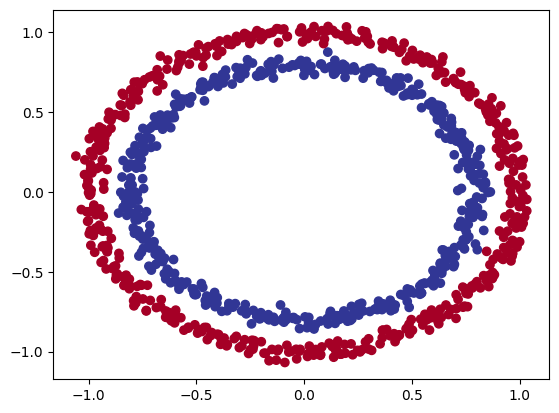

In [146]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [147]:
X, y = torch.from_numpy(X).type(torch.float), torch.from_numpy(y).type(torch.float)
X[:5]

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])

In [148]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 42)
X_train[:5]

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        [-0.9666, -0.2256],
        [-0.1666,  0.7994]])

In [149]:
len(X_train), len(X_test)

(800, 200)

In [150]:
y_train[:5]

tensor([1., 0., 0., 0., 1.])

In [151]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [152]:
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer3 = nn.Linear(in_features = 10, out_features = 1)
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

In [153]:
model = CircleModel().to(device)
model

CircleModel(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [154]:
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

X_train[:5]

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        [-0.9666, -0.2256],
        [-0.1666,  0.7994]], device='mps:0')

In [155]:
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.1)

In [156]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [157]:
epochs = 100

for epoch in range(epochs):
    model.train()

    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    train_accuracy = accuracy_fn(y_train, y_pred)

    loss = loss_fn(y_logits, y_train)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        y_test_logits = model(X_test).squeeze()
        y_test_pred = torch.round(torch.sigmoid(y_test_logits))
        test_accuracy = accuracy_fn(y_test, y_test_pred)

        test_loss = loss_fn(y_test_logits, y_test)

    if epoch % (0.2 * epochs) == 0:
        print(f"Training Loss: {loss:.5f} | Testing Loss: {test_loss:.5f}")
        print(f"Train Accuracy: {train_accuracy} | Test Accuracy: {test_accuracy}")

Training Loss: 0.69295 | Testing Loss: 0.69394
Train Accuracy: 50.0 | Test Accuracy: 50.0
Training Loss: 0.20353 | Testing Loss: 0.19835
Train Accuracy: 99.375 | Test Accuracy: 97.5
Training Loss: 0.01162 | Testing Loss: 0.02676
Train Accuracy: 100.0 | Test Accuracy: 99.5
Training Loss: 0.00364 | Testing Loss: 0.01296
Train Accuracy: 100.0 | Test Accuracy: 99.5
Training Loss: 0.00222 | Testing Loss: 0.00857
Train Accuracy: 100.0 | Test Accuracy: 100.0


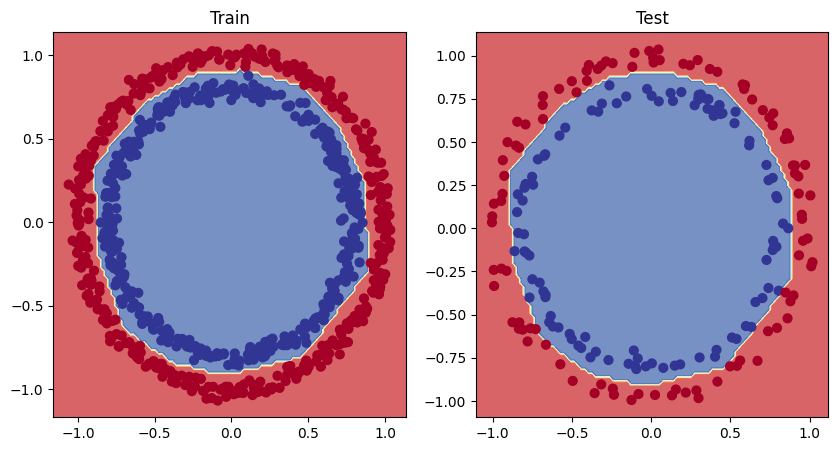

In [161]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train.cpu(), y_train.cpu())
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test.cpu(), y_test.cpu())

In [162]:
model.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 1.0047,  1.7072],
                      [-2.0996, -0.8906],
                      [-0.1549,  0.1427],
                      [-2.8653, -0.9153],
                      [ 0.5625, -2.6118],
                      [-0.3064,  1.9318],
                      [ 2.2042,  0.0219],
                      [ 0.3410, -0.0998],
                      [-1.5480,  1.3662],
                      [-0.3301,  0.1802]])),
             ('layer1.bias',
              tensor([-1.2492, -1.5440, -0.2872, -0.9629, -1.2688, -0.9070, -1.0033, -0.4252,
                      -1.1340, -0.6984])),
             ('layer2.weight',
              tensor([[-2.2037, -1.8213,  0.2441, -0.2128, -1.9895, -1.5501, -2.3465,  0.2555,
                       -1.6813, -0.0997],
                      [ 3.1210,  2.7180,  0.1331,  1.1756,  3.1033,  2.6263,  3.4258,  0.0566,
                        2.2398, -0.1927],
                      [-1.9058, -0.0835, -0.2426,  0.1947,  1.4240, -0.5809